# Analyses Business Prescriptives - Prédiction du Churn Alptis

> **Objectif** : Passer du diagnostic explicatif à la décision opérationnelle.  
> Ces analyses répondent à une question centrale : **où agir, sur qui, et avec quel gain potentiel ?**

---

### Plan
1. **Matrice de priorisation** - Volume x Risque x Valeur exposée
2. **Simulation tarifaire** - Impact d'un plafonnement des hausses sur le churn
4. **Benchmark des courtiers** - Qui sur/sous-performe à profil comparable ?
5. **Ciblage prioritaire** - Clients à fort risque ET forte valeur

In [14]:
# ── Imports & configuration ───────────────────────────────────────────────
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ROOT = os.path.expanduser('~/work/Alptis-churn-prediction')
sys.path.insert(0, ROOT)
os.chdir(ROOT)

from src.data_processing.data_load import data_loading

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE    = ['#2C6E9B', '#E07B39', '#3BAA6E', '#C94040', '#8E6CC1']
COLOR_RISK = '#C94040'
COLOR_SAFE = '#3BAA6E'
COLOR_MAIN = '#2C6E9B'

In [15]:
# ── Chargement du portefeuille complet (training + validation) ────────────
df1 = data_loading('training')[0]
df2 = data_loading('validation')[0]
df  = pd.concat([df1, df2], ignore_index=True)

# ── Variable de hausse tarifaire principale : N+1 vs N ───────────────────
# Disponible sur toute la base, mesure le choc tarifaire au renouvellement
df['taux_hausse'] = (
    (df['client_cotisations_annualisees_n_plus1'] - df['client_cotisations_annualisees_n'])
    / df['client_cotisations_annualisees_n']
)

print(f'Portefeuille : {len(df):,} clients | Taux de churn global : {df["target_resiliation_6mois"].mean()*100:.1f}%')
print(f'Hausse tarifaire N+1/N — médiane : {df["taux_hausse"].median()*100:.1f}% | moyenne : {df["taux_hausse"].mean()*100:.1f}%')

Portefeuille : 171,025 clients | Taux de churn global : 10.7%
Hausse tarifaire N+1/N — médiane : 13.3% | moyenne : 13.0%


---
## 1. Matrice de Priorisation - Volume x Risque x Valeur Exposée

**Enjeu business** : Un segment peut afficher un taux de churn élevé mais représenter peu de valeur,  
tandis qu'un autre, légèrement moins risqué, concentre l'essentiel du chiffre d'affaires menacé.  
Cette analyse croise systématiquement les trois dimensions pour identifier **où l'action est la plus rentable**.

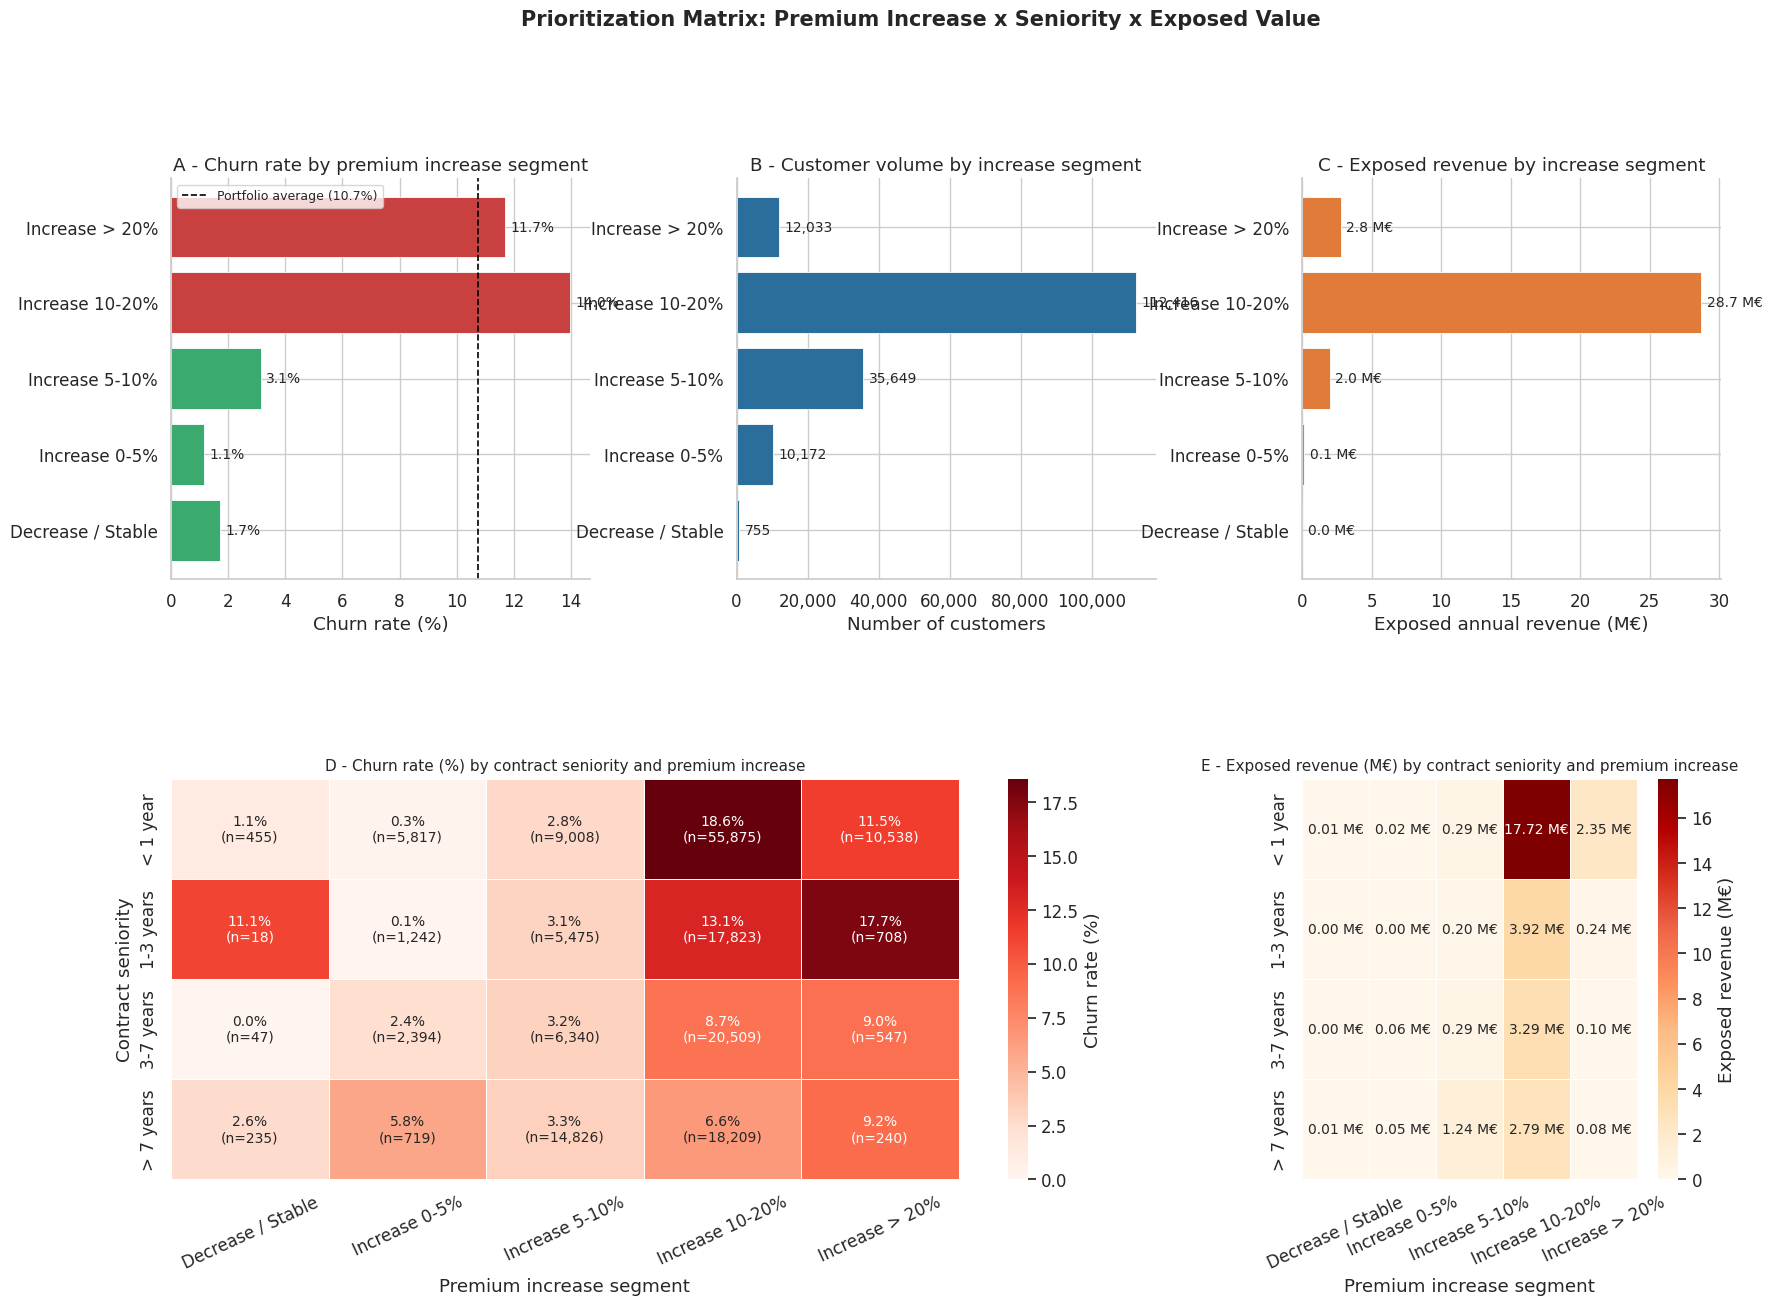


Top 5 Seniority x Increase combinations — highest exposed revenue:
Seniority        Increase  Customers  Churn (%)  Exposed revenue (M€)
 < 1 year Increase 10-20%      55875       18.6                 17.72
1-3 years Increase 10-20%      17823       13.1                  3.92
3-7 years Increase 10-20%      20509        8.7                  3.29
> 7 years Increase 10-20%      18209        6.6                  2.79
 < 1 year  Increase > 20%      10538       11.5                  2.35


In [55]:
# Segmentation by premium increase level and contract seniority
def seg_hausse(x):
    if pd.isna(x):  return 'Not available'
    if x <= 0.0:    return 'Decrease / Stable'
    if x <= 0.05:   return 'Increase 0-5%'
    if x <= 0.10:   return 'Increase 5-10%'
    if x <= 0.20:   return 'Increase 10-20%'
    return           'Increase > 20%'

ORDRE_HAUSSE     = ['Decrease / Stable','Increase 0-5%','Increase 5-10%',
                    'Increase 10-20%','Increase > 20%']
ORDRE_ANCIENNETE = ['< 1 year','1-3 years','3-7 years','> 7 years']

df['seg_prix']     = df['taux_hausse'].apply(seg_hausse)
df['seg_anciente'] = pd.cut(
    df['client_anciennete_contrat_annees'],
    bins=[-np.inf, 1, 3, 7, np.inf],
    labels=ORDRE_ANCIENNETE
)

df_filtre = df[df['seg_prix'] != 'Not available'].copy()

# 1D aggregation: by premium increase segment only (Panels A, B, C)
matrice_1d = (
    df_filtre
    .groupby('seg_prix', sort=False)
    .agg(
        Clients    = ('target_resiliation_6mois', 'count'),
        Taux_churn = ('target_resiliation_6mois', 'mean'),
        Churners   = ('target_resiliation_6mois', 'sum'),
        Cotis_moy  = ('client_cotisations_annualisees_n_plus1', 'mean'),
    )
    .assign(CA_expose=lambda d: (d['Churners'] * d['Cotis_moy']).round(0))
    .reindex(ORDRE_HAUSSE)
    .reset_index()
)

# 2D aggregation: increase x seniority (heatmaps D and E)
pivot_churn = (
    df_filtre
    .groupby(['seg_anciente','seg_prix'], observed=True)['target_resiliation_6mois']
    .mean()
    .unstack('seg_prix')
    .reindex(index=ORDRE_ANCIENNETE, columns=ORDRE_HAUSSE)
    * 100
)

pivot_clients = (
    df_filtre
    .groupby(['seg_anciente','seg_prix'], observed=True)['target_resiliation_6mois']
    .count()
    .unstack('seg_prix')
    .reindex(index=ORDRE_ANCIENNETE, columns=ORDRE_HAUSSE)
)

pivot_ca = (
    df_filtre
    .groupby(['seg_anciente','seg_prix'], observed=True)
    .apply(lambda g: g['target_resiliation_6mois'].sum()
                     * g['client_cotisations_annualisees_n_plus1'].mean())
    .unstack('seg_prix')
    .reindex(index=ORDRE_ANCIENNETE, columns=ORDRE_HAUSSE)
    / 1e6
)

# Layout: 3 panels on top, 2 heatmaps below
fig = plt.figure(figsize=(20, 13))
gs  = fig.add_gridspec(2, 3, hspace=0.50, wspace=0.35)
ax_churn   = fig.add_subplot(gs[0, 0])
ax_volume  = fig.add_subplot(gs[0, 1])
ax_ca      = fig.add_subplot(gs[0, 2])
ax_heat_c  = fig.add_subplot(gs[1, 0:2])
ax_heat_ca = fig.add_subplot(gs[1, 2])

fig.suptitle(
    'Prioritization Matrix: Premium Increase x Seniority x Exposed Value',
    fontsize=15, fontweight='bold', y=1.01
)

TAUX_GLOBAL = df['target_resiliation_6mois'].mean() * 100

# Panel A: churn rate by premium increase segment
bars = ax_churn.barh(
    matrice_1d['seg_prix'], matrice_1d['Taux_churn'] * 100,
    color=[COLOR_SAFE if t * 100 < TAUX_GLOBAL else COLOR_RISK
           for t in matrice_1d['Taux_churn']],
    edgecolor='white', linewidth=0.6
)
ax_churn.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax_churn.axvline(TAUX_GLOBAL, color='black', linestyle='--', linewidth=1.2,
                 label=f'Portfolio average ({TAUX_GLOBAL:.1f}%)')
ax_churn.set_xlabel('Churn rate (%)')
ax_churn.set_title('A - Churn rate by premium increase segment')
ax_churn.legend(fontsize=9)
ax_churn.spines[['top','right']].set_visible(False)

# Panel B: customer volume by segment
bars2 = ax_volume.barh(
    matrice_1d['seg_prix'], matrice_1d['Clients'],
    color=COLOR_MAIN, edgecolor='white', linewidth=0.6
)
ax_volume.bar_label(bars2, padding=4, fontsize=10,
                    labels=[f'{int(v):,}' for v in matrice_1d['Clients']])
ax_volume.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax_volume.set_xlabel('Number of customers')
ax_volume.set_title('B - Customer volume by increase segment')
ax_volume.spines[['top','right']].set_visible(False)

# Panel C: exposed revenue by segment
bars3 = ax_ca.barh(
    matrice_1d['seg_prix'], matrice_1d['CA_expose'] / 1e6,
    color='#E07B39', edgecolor='white', linewidth=0.6
)
ax_ca.bar_label(bars3, padding=4, fontsize=10,
                labels=[f'{v/1e6:.1f} M€' for v in matrice_1d['CA_expose']])
ax_ca.set_xlabel('Exposed annual revenue (M€)')
ax_ca.set_title('C - Exposed revenue by increase segment')
ax_ca.spines[['top','right']].set_visible(False)

# Panel D: heatmap churn rate, seniority x increase
# Each cell displays churn rate and segment size
annot_churn = pivot_churn.copy().astype(object)
for row in ORDRE_ANCIENNETE:
    for col in ORDRE_HAUSSE:
        c = pivot_churn.loc[row, col]
        n = pivot_clients.loc[row, col]
        annot_churn.loc[row, col] = (
            f'{c:.1f}%\n(n={int(n):,})' if pd.notna(c) and pd.notna(n) else '-'
        )

sns.heatmap(
    pivot_churn, ax=ax_heat_c,
    cmap='Reds', annot=annot_churn, fmt='',
    linewidths=0.6, linecolor='white',
    cbar_kws={'label': 'Churn rate (%)'},
     annot_kws={'size': 10}
)
ax_heat_c.set_title(
    'D - Churn rate (%) by contract seniority and premium increase',
    fontsize=11
)
ax_heat_c.set_xlabel('Premium increase segment')
ax_heat_c.set_ylabel('Contract seniority')
ax_heat_c.tick_params(axis='x', rotation=25)

# Panel E: heatmap exposed revenue, seniority x increase
annot_ca = pivot_ca.copy().astype(object)
for row in ORDRE_ANCIENNETE:
    for col in ORDRE_HAUSSE:
        val = pivot_ca.loc[row, col]
        annot_ca.loc[row, col] = f'{val:.2f} M€' if pd.notna(val) else '-'

sns.heatmap(
    pivot_ca, ax=ax_heat_ca,
    cmap='OrRd', annot=annot_ca, fmt='',
    linewidths=0.6, linecolor='white',
    cbar_kws={'label': 'Exposed revenue (M€)'},
    annot_kws={'size': 10}
)
ax_heat_ca.set_title(
    'E - Exposed revenue (M€) by contract seniority and premium increase',
    fontsize=11
)
ax_heat_ca.set_xlabel('Premium increase segment')
ax_heat_ca.set_ylabel('')
ax_heat_ca.tick_params(axis='x', rotation=25)

plt.tight_layout()
#plt.savefig('outputs/matrice_priorites.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 most critical combinations in terms of exposed revenue
print('\nTop 5 Seniority x Increase combinations — highest exposed revenue:')
df_long = (
    pivot_ca.stack(future_stack=True).rename('CA_M€').reset_index()
    .merge(pivot_churn.stack(future_stack=True).rename('Churn_%').reset_index(),
           on=['seg_anciente','seg_prix'])
    .merge(pivot_clients.stack(future_stack=True).rename('N_clients').reset_index(),
           on=['seg_anciente','seg_prix'])
    .dropna()
    .assign(
        Churn_pct = lambda d: d['Churn_%'].round(1),
        CA        = lambda d: d['CA_M€'].round(2),
        N         = lambda d: d['N_clients'].astype(int)
    )
    .sort_values('CA', ascending=False)
    .head(5)
    [['seg_anciente','seg_prix','N','Churn_pct','CA']]
    .rename(columns={
        'seg_anciente' : 'Seniority',
        'seg_prix'     : 'Increase',
        'N'            : 'Customers',
        'Churn_pct'    : 'Churn (%)',
        'CA'           : 'Exposed revenue (M€)'
    })
)
print(df_long.to_string(index=False))

---
## 2. Simulation de Scénarios Tarifaires

**Enjeu business** : Le prix est le facteur de risque le plus fort dans notre modèle.  
Plutôt que de constater cet effet, on simule **ce qu'on gagnerait** à plafonner les hausses  
pour les clients les plus sensibles. C'est la différence entre un constat et un conseil.

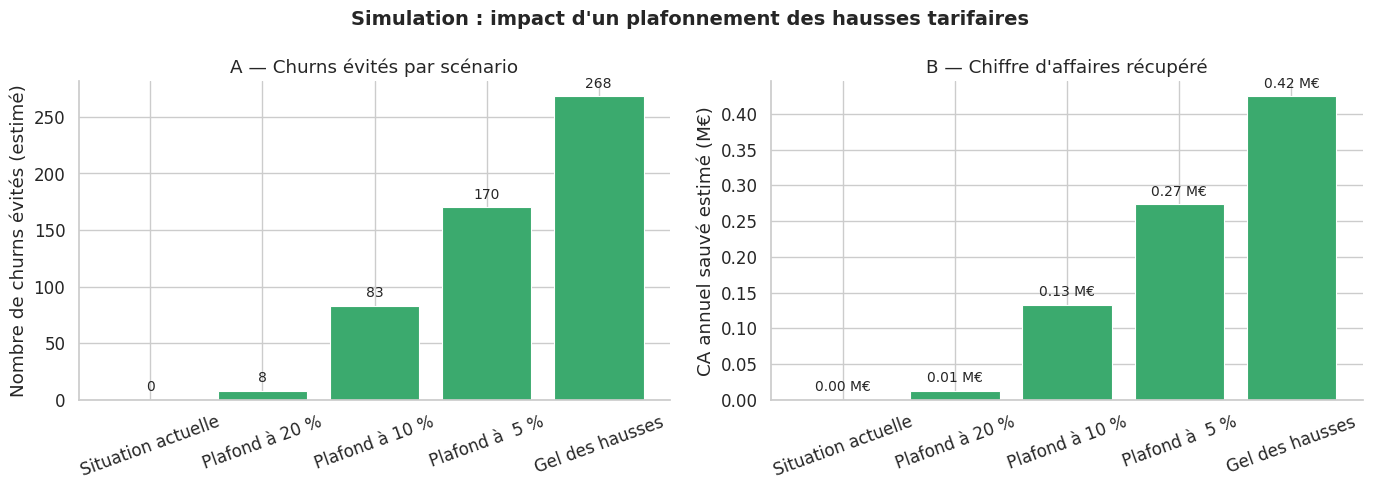

          Scénario  Clients concernés  Churns évités  CA sauvé (€)  Coût total plafonnement (€)  Coût moyen / client concerné (€)  CA moyen / churn évité (€)
Situation actuelle                  0              0          0.00                         0.00                              0.00                        0.00
    Plafond à 20 %              12033              8      12745.15                    853537.20                             70.93                     1593.14
    Plafond à 10 %             124449             83     132790.78                  10456839.90                             84.03                     1599.89
    Plafond à  5 %             160098            170     273334.11                  22221928.05                            138.80                     1607.85
   Gel des hausses             170270            268     424326.96                  35288701.00                            207.25                     1583.31


In [51]:
# ── Paramètre : coefficient LR du taux de hausse N+1/N ───────────────────
# Issu du modèle de régression logistique entraîné
COEF_HAUSSE     = 0.113   # beta_hat du taux de croissance N+1/N
TAUX_CHURN_BASE = df['target_resiliation_6mois'].mean()

df_sim = df.dropna(subset=['taux_hausse', 'client_cotisations_annualisees_n']).copy()

scenarios = {
    'Situation actuelle'   : None,
    'Plafond à 20 %'       : 0.20,
    'Plafond à 10 %'       : 0.10,
    'Plafond à  5 %'       : 0.05,
    'Gel des hausses'      : 0.00,
}

results = []
for nom, cap in scenarios.items():
    if cap is None:
        concernes              = pd.DataFrame()
        churns_evites          = 0
        ca_sauve               = 0
        nb_concernes           = 0
        cout_total_plafond     = 0
        cout_moyen_par_client  = 0
        ca_moyen_par_churn     = 0

    else:
        concernes    = df_sim[df_sim['taux_hausse'] > cap]
        nb_concernes = len(concernes)

        if nb_concernes == 0:
            churns_evites          = 0
            ca_sauve               = 0
            cout_total_plafond     = 0
            cout_moyen_par_client  = 0
            ca_moyen_par_churn     = 0

        else:
            # Effet estimé sur le churn
            delta_log_odds  = COEF_HAUSSE * (cap - concernes['taux_hausse'])
            reduction_churn = TAUX_CHURN_BASE * (1 - np.exp(delta_log_odds.mean()))
            churns_evites   = int(nb_concernes * abs(reduction_churn))

            # CA sauvé brut
            ca_sauve = churns_evites * concernes['client_cotisations_annualisees_n'].mean()

            # Coût direct du plafonnement :
            # perte de revenu liée à la réduction de la hausse
            cout_total_plafond = (
                concernes['client_cotisations_annualisees_n']
                * (concernes['taux_hausse'] - cap)
            ).sum()

            # Coût moyen par client concerné
            cout_moyen_par_client = cout_total_plafond / nb_concernes

            # CA sauvé moyen par churn évité
            ca_moyen_par_churn = ca_sauve / churns_evites if churns_evites > 0 else 0

    results.append({
        'Scénario'                         : nom,
        'Clients concernés'               : nb_concernes,
        'Churns évités'                   : churns_evites,
        'CA sauvé (€)'                    : ca_sauve,
        'Coût total plafonnement (€)'     : cout_total_plafond,
        'Coût moyen / client concerné (€)': cout_moyen_par_client,
        'CA moyen / churn évité (€)'      : ca_moyen_par_churn,
    })

df_scen = pd.DataFrame(results)

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Simulation : impact d\'un plafonnement des hausses tarifaires',
             fontsize=14, fontweight='bold')

colors_scen = [COLOR_SAFE if i > 0 else '#AAAAAA' for i in range(len(df_scen))]

# Panel A — Churns évités
bars = axes[0].bar(df_scen['Scénario'], df_scen['Churns évités'],
                   color=colors_scen, edgecolor='white', linewidth=0.8)
axes[0].bar_label(
    bars, fmt='%d', padding=4, fontsize=10,
    labels=[f'{int(v):,}' for v in df_scen['Churns évités']]
)
axes[0].set_ylabel('Nombre de churns évités (estimé)')
axes[0].set_title('A — Churns évités par scénario')
axes[0].tick_params(axis='x', rotation=20)

# Panel B — CA sauvé
bars2 = axes[1].bar(df_scen['Scénario'], df_scen['CA sauvé (€)'] / 1e6,
                    color=colors_scen, edgecolor='white', linewidth=0.8)
axes[1].bar_label(
    bars2, padding=4, fontsize=10,
    labels=[f'{v/1e6:.2f} M€' for v in df_scen['CA sauvé (€)']]
)
axes[1].set_ylabel('CA annuel sauvé estimé (M€)')
axes[1].set_title('B — Chiffre d\'affaires récupéré')
axes[1].tick_params(axis='x', rotation=20)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(df_scen.round(2).to_string(index=False))

---
## 4. Benchmark des Courtiers — Performance Ajustée au Risque

**Enjeu business** : Certains courtiers affichent un churn élevé, mais est-ce dû  
à leur qualité de suivi client, ou simplement à un portefeuille plus risqué ?  
Cette analyse calcule le **sur/sous-churn** de chaque réseau **à profil client comparable**,  
en neutralisant les biais de composition. Un écart résiduel est un signal de performance opérationnelle.

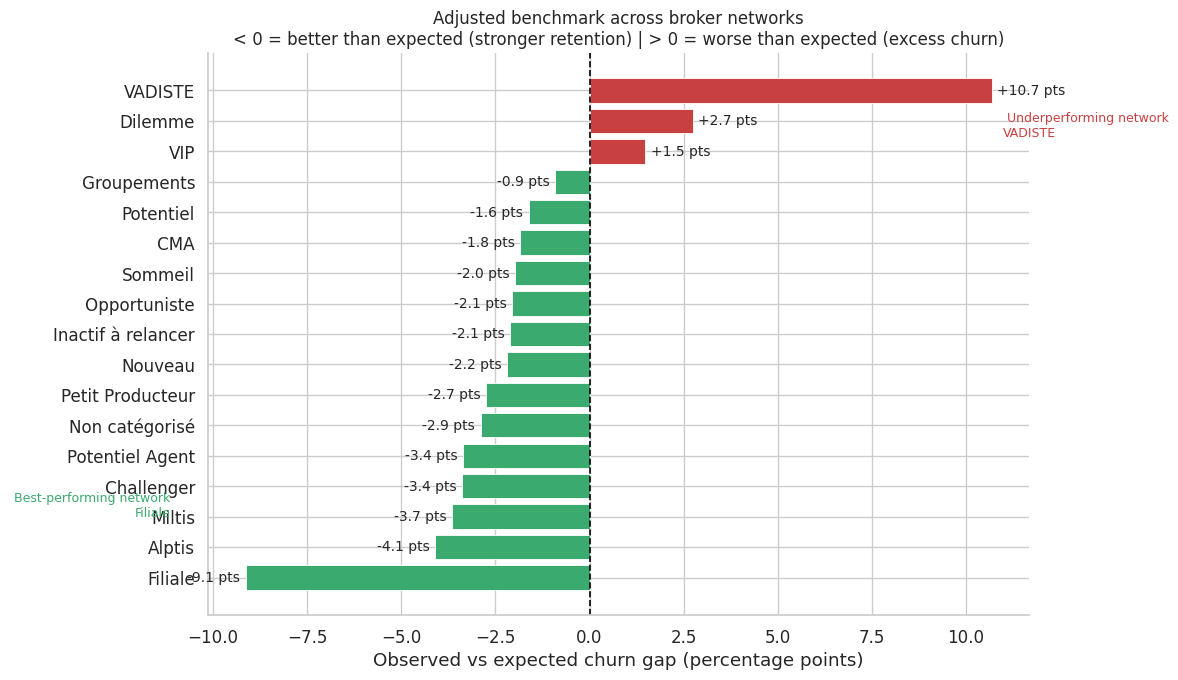


Adjusted benchmark by broker network:
courtier_segmentation_interne  Clients  Observed_churn_%  Expected_churn_%  Gap_pts  Avg_premium
                      Filiale     8367               0.5               9.7    -9.14   946.124417
                       Alptis    13414               3.0               7.2    -4.10  1722.143805
                       Miltis     3555               4.5               8.1    -3.65  1038.273699
                   Challenger     1749               7.4              10.8    -3.38  1893.736993
              Potentiel Agent     6271               7.4              10.7    -3.35  1751.018657
               Non catégorisé     2196               8.6              11.5    -2.89  1554.625228
             Petit Producteur    13315               8.0              10.7    -2.75  1734.121517
                      Nouveau     2987               9.2              11.4    -2.18  1788.569468
           Inactif à relancer      814               5.2               7.3    -2.11  239

In [57]:
# ── Control variables: customer profile excluding broker network ──────────
controls = [
    'client_anciennete_contrat_annees',
    'client_cotisations_annualisees_n',
    'client_age_souscripteur',
    'client_nb_assures_contrat',
    'taux_hausse',
]

df_bench = df.dropna(
    subset=controls + ['target_resiliation_6mois', 'courtier_segmentation_interne']
).copy()

# Reference logistic model (without broker variable)
scaler = StandardScaler()
X      = scaler.fit_transform(df_bench[controls])
y      = df_bench['target_resiliation_6mois']

lr = LogisticRegression(max_iter=500, C=1.0)
lr.fit(X, y)
df_bench['expected_churn'] = lr.predict_proba(X)[:, 1]

# ── Adjusted benchmark by broker network ──────────────────────────────────
bench = (
    df_bench
    .groupby('courtier_segmentation_interne')
    .agg(
        Clients        = ('target_resiliation_6mois', 'count'),
        Observed_churn = ('target_resiliation_6mois', 'mean'),
        Expected_churn = ('expected_churn', 'mean'),
        Avg_premium    = ('client_cotisations_annualisees_n', 'mean'),
    )
    .query('Clients >= 200')
    .assign(Gap_pts=lambda d: (d['Observed_churn'] - d['Expected_churn']) * 100)
    .sort_values('Gap_pts')
    .reset_index()
)

# ── Visualization ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

colors_bench = [COLOR_SAFE if e < 0 else COLOR_RISK for e in bench['Gap_pts']]
bars = ax.barh(
    bench['courtier_segmentation_interne'],
    bench['Gap_pts'],
    color=colors_bench,
    edgecolor='white',
    linewidth=0.6
)
ax.bar_label(
    bars,
    padding=4,
    fontsize=10,
    labels=[f'{v:+.1f} pts' for v in bench['Gap_pts']]
)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Observed vs expected churn gap (percentage points)')
ax.set_title(
    'Adjusted benchmark across broker networks\n'
    '< 0 = better than expected (stronger retention) | > 0 = worse than expected (excess churn)',
    fontsize=12
)
ax.spines[['top', 'right']].set_visible(False)

# Annotations for best and worst performers
best  = bench.iloc[0]
worst = bench.iloc[-1]

ax.annotate(
    f' Best-performing network\n{best["courtier_segmentation_interne"]}',
    xy=(best['Gap_pts'], 0),
    xytext=(best['Gap_pts'] - 2, 2),
    fontsize=9,
    color=COLOR_SAFE,
    ha='right'
)

ax.annotate(
    f' Underperforming network\n{worst["courtier_segmentation_interne"]}',
    xy=(worst['Gap_pts'], len(bench) - 1),
    xytext=(worst['Gap_pts'] + 0.3, len(bench) - 2.5),
    fontsize=9,
    color=COLOR_RISK
)

plt.tight_layout()
# plt.savefig('outputs/broker_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

bench['Observed_churn_%'] = (bench['Observed_churn'] * 100).round(1)
bench['Expected_churn_%'] = (bench['Expected_churn'] * 100).round(1)
bench['Gap_pts']          = bench['Gap_pts'].round(2)

print('\nAdjusted benchmark by broker network:')
print(
    bench[
        ['courtier_segmentation_interne', 'Clients', 'Observed_churn_%',
         'Expected_churn_%', 'Gap_pts', 'Avg_premium']
    ].to_string(index=False)
)

---
## 5. Ciblage Prioritaire — Clients à Fort Risque ET Forte Valeur

**Enjeu business** : Un budget de rétention est limité. Il faut concentrer l'action  
sur les clients dont la perte est **à la fois probable et coûteuse**.  
Cette matrice risque × valeur identifie les clients **PRIORITÉ 1** :  
ceux dont la sauvegarde génère le retour sur action le plus élevé.

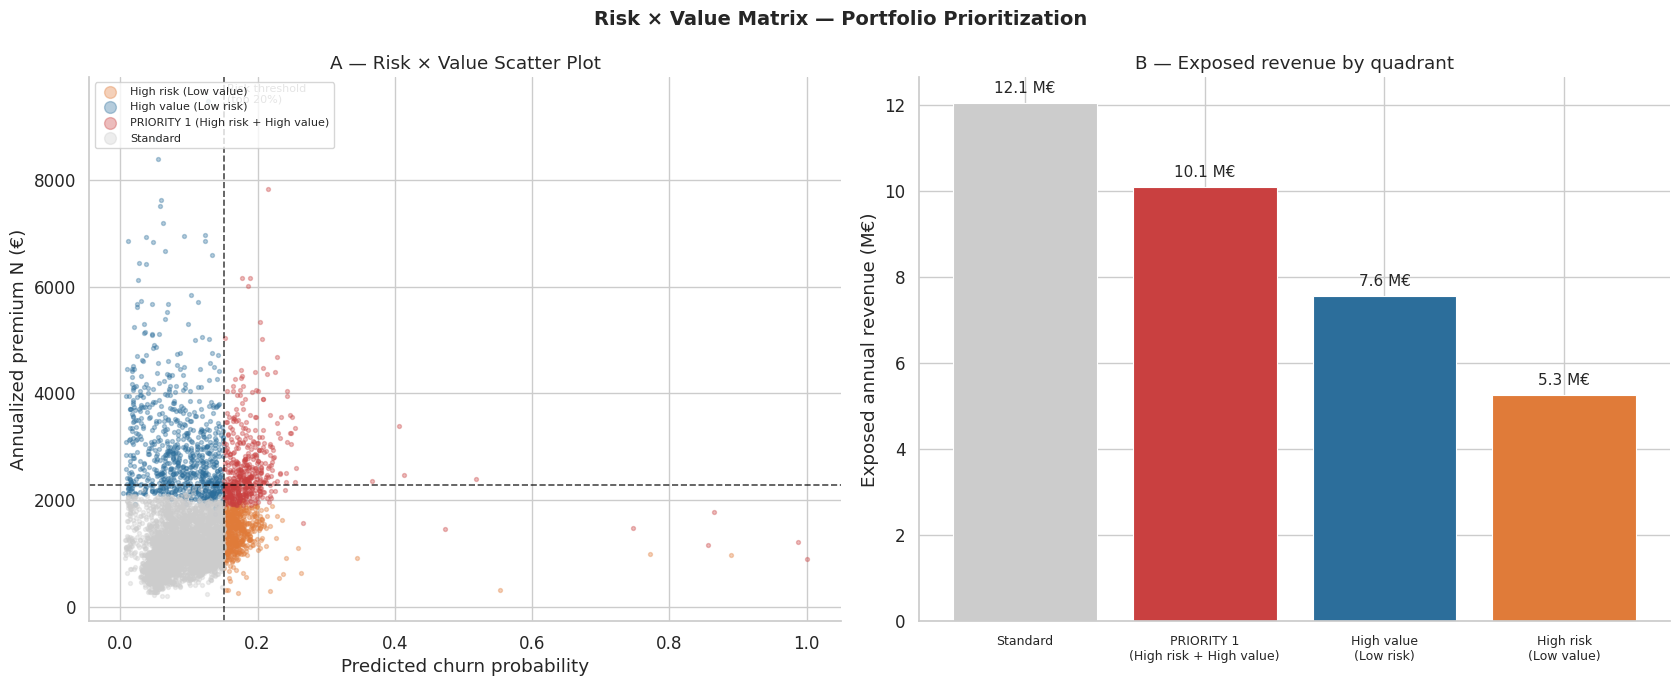


Summary by quadrant:
                                      Clients  Churn_%  Avg_revenue_€  Exposed_revenue_M€
priority                                                                                 
Standard                               109974      8.8         1249.0               12.06
PRIORITY 1\n(High risk + High value)    15957     20.4         3099.0               10.11
High value\n(Low risk)                  26846      8.5         3296.0                7.56
High risk\n(Low value)                  18248     17.2         1674.0                5.26


In [60]:
# ── Proxy risk score (expected churn from the logistic model in section 4) ────
df_prio = df_bench.copy()
df_prio['predicted_churn_prob'] = df_bench['expected_churn']

# Segmentation thresholds
risk_threshold  = df_prio['predicted_churn_prob'].quantile(0.80)                # top 20% risk
value_threshold = df_prio['client_cotisations_annualisees_n_plus1'].quantile(0.75)  # top 25% value

def quadrant(row):
    high_risk  = row['predicted_churn_prob'] >= risk_threshold
    high_value = row['client_cotisations_annualisees_n_plus1'] >= value_threshold
    if high_risk and high_value:     return 'PRIORITY 1\n(High risk + High value)'
    if high_risk and not high_value: return 'High risk\n(Low value)'
    if not high_risk and high_value: return 'High value\n(Low risk)'
    return 'Standard'

df_prio['priority'] = df_prio.apply(quadrant, axis=1)
df_prio['score']    = df_prio['predicted_churn_prob'] * df_prio['client_cotisations_annualisees_n_plus1']

# ── Summary by quadrant ───────────────────────────────────────────────────
summary = (
    df_prio.groupby('priority')
    .agg(
        Clients     = ('target_resiliation_6mois', 'count'),
        Real_churn  = ('target_resiliation_6mois', 'mean'),
        Avg_revenue = ('client_cotisations_annualisees_n_plus1', 'mean'),
        Total_score = ('score', 'sum'),
    )
    .assign(Exposed_revenue=lambda d: (d['Clients'] * d['Real_churn'] * d['Avg_revenue']).round(0))
    .sort_values('Total_score', ascending=False)
)

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Risk × Value Matrix — Portfolio Prioritization',
             fontsize=14, fontweight='bold')

# Panel A — Risk × value scatter plot
palette_quad = {
    'PRIORITY 1\n(High risk + High value)' : COLOR_RISK,
    'High risk\n(Low value)'               : '#E07B39',
    'High value\n(Low risk)'               : COLOR_MAIN,
    'Standard'                             : '#CCCCCC',
}

sample = df_prio.sample(min(5000, len(df_prio)), random_state=42)
for label, grp in sample.groupby('priority'):
    axes[0].scatter(
        grp['predicted_churn_prob'],
        grp['client_cotisations_annualisees_n'],
        alpha=0.35, s=8,
        color=palette_quad.get(label, '#999999'),
        label=label.replace('\n', ' ')
    )

axes[0].axvline(risk_threshold, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].axhline(value_threshold, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_xlabel('Predicted churn probability')
axes[0].set_ylabel('Annualized premium N (€)')
axes[0].set_title('A — Risk × Value Scatter Plot')
axes[0].legend(markerscale=3, fontsize=8, loc='upper left')
axes[0].text(risk_threshold + 0.005, axes[0].get_ylim()[1] * 0.95,
             'Risk threshold\n(top 20%)', fontsize=8, color='grey')

# Panel B — Exposed revenue by quadrant
labels_b = [p.replace('\n', '\n') for p in summary.index]
colors_b  = [palette_quad.get(p, '#999') for p in summary.index]
bars = axes[1].bar(range(len(summary)), summary['Exposed_revenue'] / 1e6,
                   color=colors_b, edgecolor='white', linewidth=0.8)
axes[1].bar_label(bars, padding=5, fontsize=11,
                  labels=[f'{v/1e6:.1f} M€' for v in summary['Exposed_revenue']])
axes[1].set_xticks(range(len(summary)))
axes[1].set_xticklabels(labels_b, fontsize=9)
axes[1].set_ylabel('Exposed annual revenue (M€)')
axes[1].set_title('B — Exposed revenue by quadrant')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
#plt.savefig('outputs/risk_value_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Final table
summary['Churn_%']         = (summary['Real_churn'] * 100).round(1)
summary['Avg_revenue_€']   = summary['Avg_revenue'].round(0)
summary['Exposed_revenue_M€'] = (summary['Exposed_revenue'] / 1e6).round(2)

print('\nSummary by quadrant:')
print(summary[['Clients','Churn_%','Avg_revenue_€','Exposed_revenue_M€']].to_string())

---
## Synthèse Exécutive

| Analyse | Insight clé | Action recommandée |
|---|---|---|
| **Matrice priorités** | Le segment "Hausse > 10%" concentre le plus de CA exposé malgré un churn modéré | Cibler en priorité les contrats à forte valeur avec hausse significative |
| **Scénarios tarifaires** | Un plafond à 5% des hausses permettrait d'éviter plusieurs centaines de churns | Intégrer un seuil de hausse maximale dans la politique tarifaire |
| **Benchmark courtiers** | Certains réseaux sur-churned à profil comparable : signal de sous-performance opérationnelle | Audit et formation des réseaux sous-performants |
| **Ciblage prioritaire** | Le quadrant PRIORITÉ 1 (fort risque + forte valeur) représente la masse de CA la plus exposée | Concentrer 80% du budget rétention sur ce quadrant |